# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

**Chapter 12: Time Series Models**

Notebook 12.2: Predicting Market Direction with Logistic Regression

Version: 2.0

Last revised: 2026-07-28

**Seven features with economic rationale, expanding-window evaluation, and why a 67% accuracy score can mean the model learned nothing.**

> Save a copy to your own Drive before running: File > Save a copy in Drive. Edits to the shared notebook are not preserved.

> This notebook requires a free FRED API key. Setup instructions are in the next cell.



---

Notebook 1 showed that ARIMA cannot forecast daily equity returns because the autocorrelation structure is too weak. But ARIMA uses only the target series itself. What if we add more information? Lagged momentum, volatility, the VIX, the yield curve: these are features with documented economic rationale that ought to help predict market direction.

This notebook tests that hypothesis using logistic regression, the simplest and most interpretable classification model. We shift to monthly frequency because daily noise is even harder to classify, and monthly returns give our features more economic meaning. We use expanding-window out-of-sample evaluation, which is the proper methodology for time-series classification (Chapter 9).

The result will reinforce what the academic literature has documented for decades: standard predictive variables fail out of sample. Even with reasonable features and correct methodology, prediction accuracy barely exceeds a naive baseline of "the market usually goes up."

**A note on the safe asset:** when the model predicts a down month, the strategy holds a risk-free position instead of SPY. For a proper backtest, we would use a tradable instrument like BIL (short-term Treasury ETF) with real prices and returns, as we have done throughout this book. Here, we use the 3-month Treasury bill rate from FRED and convert it to a monthly return. This is a simplification: we are approximating the risk-free return rather than modeling a real position. We do this because BIL only has data back to 2007, and we want the full history from 2000 onward to maximize our limited monthly observations. For the purposes of this notebook, where the goal is evaluating the classification model rather than building a deployable strategy, this approximation is acceptable.

**A note on machine learning:** this is your first introduction to a basic machine learning model. Many of the steps you see here will be expanded upon in Chapters 13 and 14. For now, focus on the key concepts that apply to any classification problem in finance:

- Predicting a category (up or down) rather than a continuous value
- Understanding a confusion matrix and a classification report
- Understanding class imbalance and why it determines the baseline your model must beat
- Understanding why overall accuracy is not always the best measure of success
- Preventing data leakage when standardizing features in a time-series context

**What we will cover:**

- Feature engineering from economic and market data, with explicit lookahead bias prevention
- Class imbalance in financial classification and why 50% is the wrong baseline
- Expanding-window out-of-sample evaluation
- Confusion matrix analysis and why overall accuracy is misleading
- Converting classification output to a trading signal and evaluating against buy-and-hold
- Feature coefficient stability over time as a diagnostic for model reliability

### FRED API Key Setup

This notebook downloads economic data from FRED (Federal Reserve Economic Data). FRED requires a free API key for programmatic access. If you do not already have one:

1. Go to https://fred.stlouisfed.org/docs/api/api_key.html
2. Create a free account (or log in if you already have one)
3. Request an API key from your account settings
4. In Google Colab, click the key icon in the left sidebar to open **Secrets**
5. Add a new secret with the name `FRED_API_KEY` and paste your key as the value
6. Toggle the **Notebook access** switch to enable it for this notebook

The cell below will retrieve the key automatically. This approach keeps your API key out of the notebook code, which is important if you share your notebooks or push them to GitHub.

In [ ]:
# ============================================================
# Setup and Configuration
# ============================================================
# Same approach as Notebook 12.1: no pinned versions because
# Colab's pre-installed numpy and scipy change frequently.
# We install the latest compatible versions and print them
# below for reproducibility.
#
# fredapi is the official Python wrapper for the FRED API.
# It requires a free API key (see the markdown cell above).
# ============================================================

!pip install fredapi scikit-learn statsmodels yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from fredapi import Fred
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
import warnings
from google.colab import userdata

warnings.filterwarnings('ignore')

# ── FRED API Key ────────────────────────────────────────────
# Retrieved from Colab Secrets. See the markdown cell above
# for instructions on setting this up.
# ────────────────────────────────────────────────────────────
FRED_API_KEY = userdata.get('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

# ── Parameters ──────────────────────────────────────────────
# All configurable values in one place. Change these to
# re-run the entire notebook with different assumptions.
# ────────────────────────────────────────────────────────────

TICKER = 'SPY'
VIX_TICKER = '^VIX'

START_DATE = '2000-01-01'
END_DATE = '2025-12-31'

# FRED series
FRED_TBILL = 'DGS3MO'      # 3-month Treasury rate (annualized %)
FRED_SPREAD = 'T10Y2Y'     # 10-Year minus 2-Year Treasury spread

# Expanding-window parameters
MIN_TRAIN_MONTHS = 60       # 5 years minimum before first prediction

# Feature construction parameters
VIX_MA_PERIOD = 90          # Trading days for VIX moving average
REALIZED_VOL_PERIOD = 21    # Trading days (~1 month) for realized vol

# Evaluation parameters
RISK_FREE_RATE = 0.0        # For Sharpe ratio calculation
TRADING_DAYS_PER_YEAR = 252
MONTHS_PER_YEAR = 12

# Data caching
CACHE_FILE = 'ch12_nb02_data.parquet'

# Print library versions for reproducibility
import sklearn
print(f"numpy:            {np.__version__}")
print(f"pandas:           {pd.__version__}")
print(f"scikit-learn:     {sklearn.__version__}")
print(f"yfinance:         {yf.__version__}")

numpy:            2.0.2
pandas:           2.2.2
scikit-learn:     1.6.1
yfinance:         0.2.66


## Section 1: Setup and Data Loading

We need data from two sources:

- **yfinance:** SPY daily prices (for returns, realized volatility, and momentum features) and VIX daily levels (for fear gauge and relative positioning features)
- **FRED:** 10Y-2Y Treasury spread (yield curve slope feature) and 3-month Treasury bill rate (safe asset return approximation)

We start with daily data and resample to monthly in the feature engineering step. All features will be constructed from data known at month-end, with a one-month lag to prevent lookahead bias.

In [ ]:
# ============================================================
# Download and Cache Data
# ============================================================
# Two separate downloads:
#   1. SPY and VIX daily prices from yfinance
#   2. T10Y2Y spread and DGS3MO T-bill rate from FRED
#
# fredapi returns a pandas Series for each FRED series.
# We combine everything into a single DataFrame and cache
# to parquet for future runs.
# ============================================================

import os

if os.path.exists(CACHE_FILE):
    print(f"Loading cached data from {CACHE_FILE}")
    df_daily = pd.read_parquet(CACHE_FILE)
else:
    # --- yfinance: SPY and VIX ---
    print("Downloading SPY and VIX from yfinance...")
    tickers = [TICKER, VIX_TICKER]
    df_yf = yf.download(tickers, start=START_DATE, end=END_DATE)['Close']
    df_yf.columns = [c.replace('^', '') for c in df_yf.columns]

    # --- FRED: Treasury spread and T-bill rate ---
    print("Downloading T10Y2Y and DGS3MO from FRED...")
    df_spread = fred.get_series('T10Y2Y',
                                observation_start=START_DATE,
                                observation_end=END_DATE)
    df_tbill = fred.get_series('DGS3MO',
                               observation_start=START_DATE,
                               observation_end=END_DATE)

    # fredapi returns a Series; convert to DataFrame with named columns
    df_spread = df_spread.to_frame(name='T10Y2Y')
    df_tbill = df_tbill.to_frame(name='DGS3MO')

    # Combine all series on a common daily index
    df_daily = df_yf.join(df_spread, how='outer').join(df_tbill, how='outer')

    # Forward-fill FRED data (not published on weekends/holidays)
    # then drop any rows where SPY is missing (non-trading days)
    df_daily = df_daily.ffill()
    df_daily = df_daily.dropna(subset=['SPY'])

    df_daily.to_parquet(CACHE_FILE)
    print(f"Saved to {CACHE_FILE}")

# Summary
print(f"\nDate range: {df_daily.index[0].strftime('%Y-%m-%d')} to "
      f"{df_daily.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(df_daily):,}")
print(f"\nColumns: {list(df_daily.columns)}")
print(f"\nFirst 5 rows:")
print(df_daily.head())
print(f"\nLast 5 rows:")
print(df_daily.tail())
print(f"\nMissing values:")
print(df_daily.isnull().sum())

Loading cached data from ch12_nb02_data.parquet

Date range: 2000-01-03 to 2025-12-31
Trading days: 6,783

Columns: ['SPY', 'VIX', 'T10Y2Y', 'DGS3MO']

First 5 rows:
                  SPY        VIX  T10Y2Y  DGS3MO
2000-01-03  91.367516  24.209999    0.20    5.48
2000-01-04  87.794495  27.010000    0.19    5.43
2000-01-05  87.951546  26.410000    0.24    5.44
2000-01-06  86.538071  25.730000    0.22    5.41
2000-01-07  91.563828  21.719999    0.21    5.38

Last 5 rows:
                   SPY    VIX  T10Y2Y  DGS3MO
2025-12-25  688.499695  13.47    0.68    3.69
2025-12-26  688.429871  13.60    0.68    3.64
2025-12-29  685.976562  14.20    0.67    3.68
2025-12-30  685.138916  14.33    0.69    3.65
2025-12-31  685.138916  14.33    0.71    3.67

Missing values:
SPY       0
VIX       0
T10Y2Y    0
DGS3MO    0
dtype: int64


We have 6,783 trading days of daily data from January 2000 through December 2025. No missing values across any of the four series.

A few things to note about the raw data:

- **T10Y2Y** is the 10-year minus 2-year Treasury spread, reported in percentage points. A negative value means the yield curve is inverted, which has historically preceded recessions. The value of 0.20 on January 3, 2000 means the 10-year yield was 0.20 percentage points above the 2-year yield.
- **DGS3MO** is the annualized 3-month T-bill rate in percent. We will convert this to a monthly return when building the strategy: monthly return = rate / 100 / 12. At 5.48% in January 2000, that is about 0.46% per month. At 3.67% in December 2025, about 0.31% per month.
- **Christmas Day (2025-12-25)** appears because of our forward-fill logic: FRED published data on that date but the market was closed. The SPY price is carried forward from December 24. This will not affect our results because we resample to month-end in the next step.

Next we build the monthly feature matrix.

## Section 2: Feature Engineering

Every feature must satisfy one rule: it can only use information available at the end of month T to predict the direction of month T+1. Any violation of this rule is lookahead bias, and it will inflate the model's accuracy in a way that is impossible to replicate in live trading.

Our features, all sampled at month-end:

- **ret_1m:** SPY return over the past 1 month (short-term momentum or mean-reversion)
- **ret_3m:** SPY return over the past 3 months (medium-term momentum)
- **ret_12m:** SPY return over the past 12 months (long-term momentum, the academic "12-1" factor)
- **vix_level:** VIX closing value (fear gauge; elevated VIX may predict positive future returns through the volatility risk premium)
- **vix_vs_ma:** ratio of VIX to its 90-day moving average (same logic as the VIXY case study; values above 1.0 indicate current fear is above recent average)
- **realized_vol:** annualized 21-day realized volatility of SPY (recent turbulence)
- **yield_spread:** 10Y-2Y Treasury spread (yield curve slope; inversions have historically preceded market downturns)

The target variable is binary: 1 if next month's SPY return is positive, 0 if negative or zero.

In [ ]:
# ============================================================
# Build Monthly Feature Matrix
# ============================================================
# Process:
#   1. Compute daily intermediate series (returns, VIX MA,
#      realized vol) from the raw daily data
#   2. Resample everything to month-end
#   3. Build features from month-end values
#   4. Create the target: did SPY go up next month?
#   5. Lag all features by one month to prevent lookahead bias
#
# The critical step is #5. Without it, the model would be
# using month T's return to predict month T's direction,
# which is not a prediction at all.
# ============================================================

# --- Step 1: Daily intermediate series ---

# Daily SPY simple returns
df_daily['SPY_return'] = df_daily['SPY'].pct_change()

# VIX 90-day moving average (computed daily, sampled at month-end)
df_daily['VIX_MA'] = df_daily['VIX'].rolling(window=VIX_MA_PERIOD).mean()

# 21-day realized volatility (annualized)
df_daily['realized_vol'] = (
    df_daily['SPY_return'].rolling(window=REALIZED_VOL_PERIOD).std()
    * np.sqrt(TRADING_DAYS_PER_YEAR)
)

# --- Step 2: Resample to month-end ---
# Use last trading day of each month for all values
df_monthly = df_daily.resample('ME').last().copy()

# Monthly SPY returns (calculated from month-end prices)
df_monthly['monthly_return'] = df_monthly['SPY'].pct_change()

# --- Step 3: Build features ---
# All computed from data known at end of month T
df_monthly['ret_1m'] = df_monthly['monthly_return']
df_monthly['ret_3m'] = df_monthly['SPY'].pct_change(3)
df_monthly['ret_12m'] = df_monthly['SPY'].pct_change(12)
df_monthly['vix_level'] = df_monthly['VIX']
df_monthly['vix_vs_ma'] = df_monthly['VIX'] / df_monthly['VIX_MA']
df_monthly['realized_vol'] = df_monthly['realized_vol']
df_monthly['yield_spread'] = df_monthly['T10Y2Y']

# Safe asset monthly return (annualized T-bill rate / 100 / 12)
df_monthly['safe_return'] = df_monthly['DGS3MO'] / 100 / MONTHS_PER_YEAR

# --- Step 4: Create target ---
# Target = 1 if NEXT month's return is positive, 0 otherwise.
# shift(-1) looks one month into the future, which is what we
# are trying to predict. This is NOT lookahead bias because the
# target is what we evaluate against, not what the model sees.
df_monthly['target'] = (df_monthly['monthly_return'].shift(-1) > 0).astype(int)

# --- Step 5: Lag features by one month ---
# The model uses features from month T to predict month T+1.
# By shifting features forward (or equivalently, aligning features
# at T with target at T+1), we ensure no overlap.
feature_cols = [
    'ret_1m', 'ret_3m', 'ret_12m',
    'vix_level', 'vix_vs_ma', 'realized_vol',
    'yield_spread'
]

# The target at row T already represents NEXT month's direction
# (because of the shift(-1) above), so features at row T are
# aligned with the prediction for month T+1. No additional
# shift is needed. The features use information through end of
# month T, and the target is month T+1's outcome.

# Drop rows with NaN (from rolling windows and the target shift)
df_model = df_monthly[feature_cols + ['target', 'monthly_return', 'safe_return']].dropna()

# --- Summary ---
print(f"Monthly observations: {len(df_model)}")
print(f"Date range: {df_model.index[0].strftime('%Y-%m-%d')} to "
      f"{df_model.index[-1].strftime('%Y-%m-%d')}")
print(f"\nTarget distribution:")
print(f"  Up months (target=1):   {df_model['target'].sum()} "
      f"({df_model['target'].mean()*100:.1f}%)")
print(f"  Down months (target=0): {(df_model['target']==0).sum()} "
      f"({(df_model['target']==0).mean()*100:.1f}%)")
print(f"\nFeature summary:")
print(df_model[feature_cols].describe().round(4))

Monthly observations: 300
Date range: 2001-01-31 to 2025-12-31

Target distribution:
  Up months (target=1):   194 (64.7%)
  Down months (target=0): 106 (35.3%)

Feature summary:
         ret_1m    ret_3m   ret_12m  vix_level  vix_vs_ma  realized_vol  \
count  300.0000  300.0000  300.0000   300.0000   300.0000      300.0000   
mean     0.0080    0.0238    0.0947    19.7164     1.0104        0.1568   
std      0.0435    0.0749    0.1686     7.9127     0.2257        0.1057   
min     -0.1652   -0.2964   -0.4342     9.5100     0.6963        0.0428   
25%     -0.0158   -0.0155    0.0144    13.9875     0.8736        0.0937   
50%      0.0129    0.0346    0.1287    17.4200     0.9574        0.1311   
75%      0.0349    0.0722    0.1929    23.4250     1.0960        0.1853   
max      0.1270    0.2605    0.5623    59.8900     2.7329        0.9354   

       yield_spread  
count      300.0000  
mean         1.1094  
std          0.9533  
min         -1.0600  
25%          0.2775  
50%          

We have 300 monthly observations from January 2001 through December 2025. The data starts in 2001 rather than 2000 because the 12-month return feature (`ret_12m`) requires a full year of history.

The target distribution is the most important number on this page:

- **64.7% of months were positive.** This means a model that always predicts "up" regardless of any feature would be correct 64.7% of the time. That is the naive baseline. Any model we build must beat 64.7%, not 50%. A model with 60% accuracy is not "pretty good"; it is worse than ignoring the features entirely.

The feature summary statistics look reasonable:

- **ret_1m** averages 0.80% per month with a standard deviation of 4.35%, consistent with long-run equity behavior
- **vix_vs_ma** centers near 1.0 as expected, with a range from 0.70 (calm relative to recent history) to 2.73 (the March 2020 spike, far above its recent average)
- **yield_spread** has a mean of 1.11 with a minimum of -1.06, capturing the yield curve inversions of the early 2000s, 2006-2007, 2019, and 2022-2023

Before building the model, we should check how these features relate to the target and to each other.

In [ ]:
# ============================================================
# Exploratory Analysis: Feature-Target Relationships
# ============================================================
# Two things we need to understand before modeling:
#
# 1. How correlated is each feature with the target?
#    Weak correlations preview the difficulty: if no individual
#    feature is strongly associated with next month's direction,
#    a linear model combining them is unlikely to do much better.
#
# 2. How correlated are the features with each other?
#    Highly correlated features provide redundant information.
#    This is not fatal for logistic regression but it inflates
#    coefficient standard errors and makes interpretation harder.
# ============================================================

# --- Feature-target correlations ---
print("Feature correlations with target (next month direction):")
print("=" * 55)
correlations = df_model[feature_cols].corrwith(df_model['target']).sort_values()
for feat, corr in correlations.items():
    bar = "█" * int(abs(corr) * 100)
    sign = "+" if corr > 0 else "-"
    print(f"  {feat:>15s}:  {sign}{abs(corr):.4f}  {bar}")

# --- Feature-feature correlation matrix ---
print(f"\nFeature correlation matrix:")
print(df_model[feature_cols].corr().round(3))

Feature correlations with target (next month direction):
     realized_vol:  -0.0769  ███████
        vix_level:  -0.0706  ███████
     yield_spread:  -0.0511  █████
        vix_vs_ma:  -0.0176  █
           ret_3m:  +0.0392  ███
          ret_12m:  +0.0644  ██████
           ret_1m:  +0.0748  ███████

Feature correlation matrix:
              ret_1m  ret_3m  ret_12m  vix_level  vix_vs_ma  realized_vol  \
ret_1m         1.000   0.536    0.286     -0.443     -0.614        -0.437   
ret_3m         0.536   1.000    0.487     -0.575     -0.467        -0.631   
ret_12m        0.286   0.487    1.000     -0.586     -0.042        -0.543   
vix_level     -0.443  -0.575   -0.586      1.000      0.462         0.836   
vix_vs_ma     -0.614  -0.467   -0.042      0.462      1.000         0.437   
realized_vol  -0.437  -0.631   -0.543      0.836      0.437         1.000   
yield_spread  -0.030  -0.032   -0.064      0.269     -0.013         0.130   

              yield_spread  
ret_1m              -0

The feature-target correlations are uniformly weak. The strongest is `ret_1m` at +0.075, meaning last month's return explains less than 1% of the variance in next month's direction. Every other feature is similarly feeble.

Two important caveats about this analysis:

- **Correlations measure linear relationships only.** A feature could have strong predictive power through a nonlinear relationship (for example, extreme VIX values predicting positive returns while moderate values predict nothing) and still show near-zero correlation. We would need mutual information scores or nonlinear models to detect that, which is exactly what Chapter 14 explores with tree-based models.
- **Logistic regression is also a linear model.** It finds a linear combination of features and passes that through a sigmoid function. So even if nonlinear relationships exist in the data, this model cannot capture them. The weakness we see in the correlations will carry directly into the model's predictions. We are deliberately starting with the simplest tool to establish a baseline.

The feature-feature correlation matrix reveals substantial redundancy:

- **vix_level and realized_vol (0.836):** these are measuring similar things. When the market has been volatile, implied volatility (VIX) is high. Including both gives the model two versions of the same information.
- **ret_1m and vix_vs_ma (-0.614):** a strong recent decline pushes VIX above its moving average, so these features move together. Same for ret_3m and realized_vol (-0.631).
- **yield_spread** is the most independent feature, with correlations below 0.27 against everything else. If any feature has unique information to contribute, it is this one.

We could drop the redundant features, but with only seven features and a linear model, multicollinearity will not cause numerical problems. It will widen the confidence intervals on individual coefficients, but we care about overall prediction accuracy, not interpreting individual coefficients as causal effects.

With 300 monthly observations, 7 features, and correlations this weak, expectations should be calibrated accordingly (meaning: don't get your hopes up here! This is not designed to be a good model). We proceed to the expanding-window evaluation.

## Section 3: Expanding-Window Out-of-Sample Evaluation

### Why expanding window, not a single train/test split?

A single split (say, train on 2001-2018, test on 2019-2025) gives you one draw from one point in time. If the model happens to work well in that particular test window, you learn nothing about whether it works in general. If it fails, you do not know whether it was the model or the market regime.

Expanding-window evaluation fixes this:

1. Start with the first `MIN_TRAIN_MONTHS` months (60, roughly 2001-2005) as the initial training set
2. Fit the model on the training set
3. Predict the next month's direction (one step ahead)
4. Record the prediction and the actual outcome
5. Add that month to the training set (the window expands)
6. Repeat until the end of the series

This produces one out-of-sample prediction per month, each made using only data available at the time. We get roughly 240 predictions instead of one test set, giving us a much more reliable picture of the model's performance across different market regimes.

### Why expanding rather than rolling?

With only 300 monthly observations, a rolling window would discard early data as it moves forward. Expanding keeps all prior history in the training set, which helps a parametric model like logistic regression that benefits from more observations. For tree-based models with hundreds of features (Chapter 14), rolling windows are sometimes preferable because old data may reflect a different market regime. For a simple linear model with seven features, more data is better.

### Standardization within the loop

One critical detail: we standardize features (subtract mean, divide by standard deviation) using only the training data at each step. If we standardized on the full dataset before the loop, every prediction would contain information from the future. This is the same full-sample normalization error we demonstrated in Chapter 10, Notebook 1.

**Note: logisitc regression requires standardization when using scikit-learn**

In [ ]:
# ============================================================
# Expanding-Window Out-of-Sample Evaluation
# ============================================================
# For each month beyond the initial training window:
#   1. Train on all months from the start through month T
#   2. Standardize features using ONLY training data means
#      and standard deviations (prevents lookahead bias)
#   3. Fit logistic regression on the standardized training set
#   4. Standardize month T+1's features using the same
#      training statistics (NOT the test month's own values)
#   5. Predict month T+1's direction
#   6. Record the prediction and the actual outcome
#   7. Expand the training window to include month T+1
#   8. Repeat
#
# We also store the model coefficients at each step so we can
# examine their stability over time (Section 5).
# ============================================================

X = df_model[feature_cols].values
y = df_model['target'].values
dates = df_model.index

# Storage for results
predictions = []
actuals = []
prediction_dates = []
coefficients = []       # Store coefficients at each step
intercepts = []         # Store intercept at each step

print(f"Expanding-window evaluation")
print(f"  Total months: {len(X)}")
print(f"  Initial training window: {MIN_TRAIN_MONTHS} months")
print(f"  Predictions to generate: {len(X) - MIN_TRAIN_MONTHS}\n")

for t in range(MIN_TRAIN_MONTHS, len(X)):

    # --- Split: everything up to month t is training ---
    X_train = X[:t]
    y_train = y[:t]

    # The test point is a single month
    X_test = X[t:t+1]
    y_test = y[t]

    # --- Standardize using ONLY training statistics ---
    # This is critical. The scaler learns mean and std from
    # training data only, then applies the same transformation
    # to the test point. No future information leaks in.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- Fit logistic regression ---
    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # --- Predict ---
    pred = model.predict(X_test_scaled)[0]

    # --- Store results ---
    predictions.append(pred)
    actuals.append(y_test)
    prediction_dates.append(dates[t])
    coefficients.append(model.coef_[0].copy())
    intercepts.append(model.intercept_[0])

print(f"Evaluation complete: {len(predictions)} out-of-sample predictions")

# Build results DataFrame
df_results = pd.DataFrame({
    'prediction': predictions,
    'actual': actuals
}, index=prediction_dates)

# Store coefficients for later analysis
df_coefs = pd.DataFrame(
    coefficients,
    columns=feature_cols,
    index=prediction_dates
)

print(f"Evaluation period: {df_results.index[0].strftime('%Y-%m-%d')} to "
      f"{df_results.index[-1].strftime('%Y-%m-%d')}")

Expanding-window evaluation
  Total months: 300
  Initial training window: 60 months
  Predictions to generate: 240

Evaluation complete: 240 out-of-sample predictions
Evaluation period: 2006-01-31 to 2025-12-31


We generated 240 out-of-sample predictions covering January 2006 through December 2025. Each prediction was made using only data available at the time, with features standardized on training data only.

The evaluation period starts in 2006 because the first 60 months (2001-2005) were consumed by the initial training window. This means our test period includes the 2008 financial crisis, the 2020 COVID crash, and the 2022 rate-hiking drawdown, giving us a reasonable sample of different market regimes.

Now we evaluate the predictions. Remember the baseline: the market went up in 64.7% of all months in our dataset. The model must beat that number to justify its existence.

In [ ]:
# ============================================================
# Out-of-Sample Accuracy and Confusion Matrix
# ============================================================
# We evaluate the model on three levels:
#
# 1. Overall accuracy vs. the naive baseline (always predict up)
#
# 2. Confusion matrix: a 2x2 table showing how predictions
#    map to outcomes. The four cells are:
#      - True Positive (TP):  predicted up, actually up
#      - False Positive (FP): predicted up, actually down
#      - True Negative (TN):  predicted down, actually down
#      - False Negative (FN): predicted down, actually up
#
# 3. Classification report: precision, recall, and F1-score
#    for each class. These matter more than overall accuracy
#    when classes are imbalanced, because a model can achieve
#    high accuracy by always predicting the majority class.
# ============================================================

# --- Overall accuracy ---
accuracy = accuracy_score(df_results['actual'], df_results['prediction'])

# Naive baseline: always predict "up" (majority class)
naive_accuracy = df_results['actual'].mean()

print("Out-of-Sample Results")
print("=" * 55)
print(f"  Model accuracy:         {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  Naive baseline (all up): {naive_accuracy:.4f} ({naive_accuracy*100:.1f}%)")
print(f"  Edge over baseline:     {(accuracy - naive_accuracy)*100:+.1f} percentage points")

# --- Prediction distribution ---
n_pred_up = (df_results['prediction'] == 1).sum()
n_pred_down = (df_results['prediction'] == 0).sum()
print(f"\n  Predicted up:   {n_pred_up} ({n_pred_up/len(df_results)*100:.1f}%)")
print(f"  Predicted down: {n_pred_down} ({n_pred_down/len(df_results)*100:.1f}%)")

# --- Confusion matrix ---
cm = confusion_matrix(df_results['actual'], df_results['prediction'])
print(f"\nConfusion Matrix:")
print(f"                    Predicted Down  Predicted Up")
print(f"  Actual Down       {cm[0,0]:>10d}     {cm[0,1]:>10d}")
print(f"  Actual Up         {cm[1,0]:>10d}     {cm[1,1]:>10d}")

# --- Classification report ---
print(f"\nClassification Report:")
print(classification_report(
    df_results['actual'],
    df_results['prediction'],
    target_names=['Down', 'Up'],
    digits=4
))

Out-of-Sample Results
  Model accuracy:         0.6708 (67.1%)
  Naive baseline (all up): 0.6708 (67.1%)
  Edge over baseline:     +0.0 percentage points

  Predicted up:   220 (91.7%)
  Predicted down: 20 (8.3%)

Confusion Matrix:
                    Predicted Down  Predicted Up
  Actual Down               10             69
  Actual Up                 10            151

Classification Report:
              precision    recall  f1-score   support

        Down     0.5000    0.1266    0.2020        79
          Up     0.6864    0.9379    0.7927       161

    accuracy                         0.6708       240
   macro avg     0.5932    0.5322    0.4973       240
weighted avg     0.6250    0.6708    0.5982       240



### How to read a confusion matrix

The confusion matrix is a 2x2 table that shows every combination of what the model predicted and what actually happened. Each cell has a name:

|  | Predicted Down | Predicted Up |
|---|---|---|
| **Actual Down** | True Negative (TN): 10 | False Positive (FP): 69 |
| **Actual Up** | False Negative (FN): 10 | True Positive (TP): 151 |

Reading each cell:

- **True Negative (10):** the model predicted "down" and the market actually went down. These are correct bearish calls. There were only 10 of them.
- **False Positive (69):** the model predicted "up" but the market went down. These are the costly errors: the strategy stayed in SPY during a losing month. There were 69 of them, far more than the true negatives.
- **False Negative (10):** the model predicted "down" but the market went up. These are missed opportunities: the strategy sat in T-bills while SPY rose.
- **True Positive (151):** the model predicted "up" and the market went up. These are correct bullish calls. The model got 151 of these, which sounds impressive until you realize it predicted "up" 220 times out of 240.

### What the confusion matrix reveals

The model predicted "up" 91.7% of the time. Out of 79 actual down months, it only identified 10 of them. It is not making informed predictions; it has learned that the market usually goes up and is overwhelmingly betting on that. This is the class imbalance problem in action: the model achieves 67.1% accuracy by doing almost exactly what the naive "always predict up" strategy does.

### How to read a classification report

The classification report breaks down performance for each class separately. This is essential when classes are imbalanced because overall accuracy hides what is happening inside each class.

- **Precision** answers: "when the model predicted this class, how often was it right?"
  - Down precision (0.50): when the model predicted "down," it was correct half the time. The other half were months that actually went up. A coin flip.
  - Up precision (0.69): when the model predicted "up," it was correct 69% of the time. This is close to the base rate of up months (67.1%), meaning the model adds almost nothing over naive guessing.

- **Recall** answers: "of all the months that actually were this class, how many did the model catch?"
  - Down recall (0.13): the model identified only 13% of actual down months. It missed 69 out of 79 down months entirely. This is the critical failure: the only reason you would use a direction model is to avoid down months, and this model misses 87% of them.
  - Up recall (0.94): the model caught 94% of up months, which sounds good but is trivial when the model predicts "up" 92% of the time.

- **F1-score** is the harmonic mean of precision and recall, balancing both into a single number. The down-class F1 of 0.20 confirms that the model is effectively useless for identifying down months.

### The bottom line

The model's 67.1% accuracy is identical to the naive baseline. It achieved this by learning the simplest possible rule: predict "up" almost every time. The features (momentum, VIX, yield curve, volatility) were too weakly correlated with next-month direction to shift the model away from the base rate. This is the chapter text discussion of accuracy vs. precision vs. recall in concrete form: a model can look "67% accurate" while providing zero actionable information.

The chapter text covers these concepts in more detail. What matters here is the practical takeaway: overall accuracy alone never tells you whether a classification model is useful. Always examine the confusion matrix and the per-class precision and recall, particularly for the minority class (down months), because that is where the value of a direction model lives or dies.

### Why show results this poor?

Because this is exactly the result that most people never see. Online tutorials stop at "67% accuracy" and move on. They do not show you the confusion matrix. They do not compare against the naive baseline. They do not tell you that the model learned nothing beyond "the market usually goes up."

We are showing this because it is the truth, and because understanding why it happens is more valuable than any model:

- **Seven features with documented economic rationale were not enough.** Momentum, volatility, fear, and the yield curve are not random choices. These are the variables that decades of academic research have identified as potential predictors. If they cannot produce an edge in a simple linear model, that tells you something fundamental about the difficulty of the problem.
- **Monthly frequency did not help.** We moved from daily returns (Notebook 1) to monthly specifically to reduce noise and give the features more economic meaning. The noise is lower, but the predictability is not higher.
- **This is consistent with the academic evidence.** Welch and Goyal (2008) tested a comprehensive set of predictive variables for equity returns and found that they consistently fail out of sample. Our result, with different features and a different model, arrives at the same conclusion 17 years later.

The common thread across Notebooks 1 and 2 is not that the models are bad. ARIMA is a sound time-series model. Logistic regression is a sound classifier. The problem is the input: market prices and standard market indicators do not contain enough information to reliably predict future direction. This is not a modeling failure. It is a reflection of how competitive and efficient equity markets are at absorbing publicly available information.

We still convert the predictions to a trading signal below, because seeing the equity curve reinforces the point in a way that statistics alone cannot. Plus as I have said many times througout this book, it is the process that matters right now.

In [ ]:
# ============================================================
# Convert Predictions to Trading Signal and Strategy Returns
# ============================================================
# Signal logic (same generous assumptions as Notebook 1):
#   prediction = 1 (up)   →  hold SPY for that month
#   prediction = 0 (down) →  hold T-bills for that month
#
# The safe asset return is the 3-month T-bill rate converted
# to a monthly return. This is an approximation, not a real
# traded position (see the note in the introduction).
#
# No transaction costs, no slippage, perfect execution at
# month-end. If the model cannot beat buy-and-hold under
# these ideal conditions, it has no chance in practice.
# ============================================================

# Align monthly returns and safe asset returns with predictions
df_eval = df_results.copy()
df_eval['monthly_return'] = df_model.loc[df_eval.index, 'monthly_return'].shift(-1)
df_eval['safe_return'] = df_model.loc[df_eval.index, 'safe_return']

# Drop the last row (no future return available)
df_eval = df_eval.dropna()

# Strategy return: SPY when predicted up, T-bills when predicted down
df_eval['strategy_return'] = (
    df_eval['prediction'] * df_eval['monthly_return'] +
    (1 - df_eval['prediction']) * df_eval['safe_return']
)

# Buy-and-hold benchmark: 100% SPY every month
df_eval['buyhold_return'] = df_eval['monthly_return']

# Cumulative returns (growth of $1)
df_eval['strategy_cumulative'] = (1 + df_eval['strategy_return']).cumprod()
df_eval['buyhold_cumulative'] = (1 + df_eval['buyhold_return']).cumprod()

print(f"Strategy evaluation period: {df_eval.index[0].strftime('%Y-%m-%d')} to "
      f"{df_eval.index[-1].strftime('%Y-%m-%d')}")
print(f"Months evaluated: {len(df_eval)}")

Strategy evaluation period: 2006-01-31 to 2025-11-30
Months evaluated: 239


In [ ]:
# ============================================================
# Inline Performance Evaluation
# ============================================================
# Same metrics as Notebook 1, adapted for monthly returns.
# Remember we are keepings things simple here and not using our
# chapter 7 toolkit.
# Annualization uses 12 months per year instead of 252 days.
# ============================================================

def calc_monthly_metrics(returns, label, hit_rate=None):
    """
    Calculate standard performance metrics from a monthly
    return series. Annualizes using 12 months per year.
    """
    # Total cumulative return
    cum_return = (1 + returns).cumprod().iloc[-1] - 1

    # Annualized return (CAGR)
    n_years = len(returns) / MONTHS_PER_YEAR
    cagr = (1 + cum_return) ** (1 / n_years) - 1

    # Annualized volatility (monthly std * sqrt(12))
    ann_vol = returns.std() * np.sqrt(MONTHS_PER_YEAR)

    # Sharpe ratio
    sharpe = (cagr - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0.0

    # Maximum drawdown
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()

    metrics = {
        'Total Return': f"{cum_return:.2%}",
        'CAGR': f"{cagr:.2%}",
        'Ann. Volatility': f"{ann_vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.2%}",
    }
    if hit_rate is not None:
        metrics['Hit Rate'] = f"{hit_rate:.2%}"

    return metrics

# Calculate metrics for both strategy and benchmark
strategy_metrics = calc_monthly_metrics(
    df_eval['strategy_return'],
    'Logistic Regression Strategy',
    hit_rate=accuracy
)
buyhold_metrics = calc_monthly_metrics(
    df_eval['buyhold_return'],
    'SPY Buy-and-Hold'
)

# Build comparison table
df_comparison = pd.DataFrame({
    'Logistic Regression': strategy_metrics,
    'SPY Buy-and-Hold': buyhold_metrics
})

print(df_comparison.to_string())

                Logistic Regression SPY Buy-and-Hold
Total Return                670.50%          680.56%
CAGR                         10.80%           10.87%
Ann. Volatility              13.82%           15.09%
Sharpe Ratio                   0.78             0.72
Max Drawdown                -28.38%          -50.78%
Hit Rate                     67.08%              NaN


The performance table delivers a surprise. Despite a classification report that looked useless, the backtest is respectable:

- **CAGR is nearly identical** (10.80% vs. 10.87%), meaning the strategy kept pace with buy-and-hold over 20 years
- **Max drawdown is almost half** (-28.38% vs. -50.78%), meaning the model's rare "down" predictions avoided some of the worst months
- **Sharpe ratio is slightly higher** (0.78 vs. 0.72), reflecting the lower volatility from those defensive calls

This leads to an important lesson that applies in both directions: **classification metrics and trading performance do not always agree.**

A model can have a poor classification report and still produce a reasonable backtest. Our model predicted "down" only 20 times out of 240 months, and its precision on those calls was only 50%. But if those 10 correct "down" calls happened to land on months like October 2008, March 2020, or September 2022, avoiding even a few of the largest drawdowns has an outsized effect on cumulative performance. The model does not need to be right often if it is occasionally right at the right time.

The reverse is also true. A model with an impressive classification report can produce a terrible backtest. If the model correctly predicts many small up months but misses the handful of large down months (or misses the large up months by being too cautious), the equity curve will suffer despite high overall accuracy.

The takeaway: always evaluate both the classification metrics and the trading performance. They measure different things, and neither one alone gives you the full picture. The confusion matrix tells you how the model is behaving statistically. The equity curve tells you what that behavior means in dollars.

That said, do not mistake this result for evidence that the model works. The CAGR is no better than buy-and-hold, the drawdown improvement may be a product of this particular sample period, and with only 20 "down" predictions the result is statistically fragile. A few of those calls landing differently would change the picture entirely.

But please remember this key message: the ultimate test of any strategy is not the classification report nor the backtest. It is live trading.

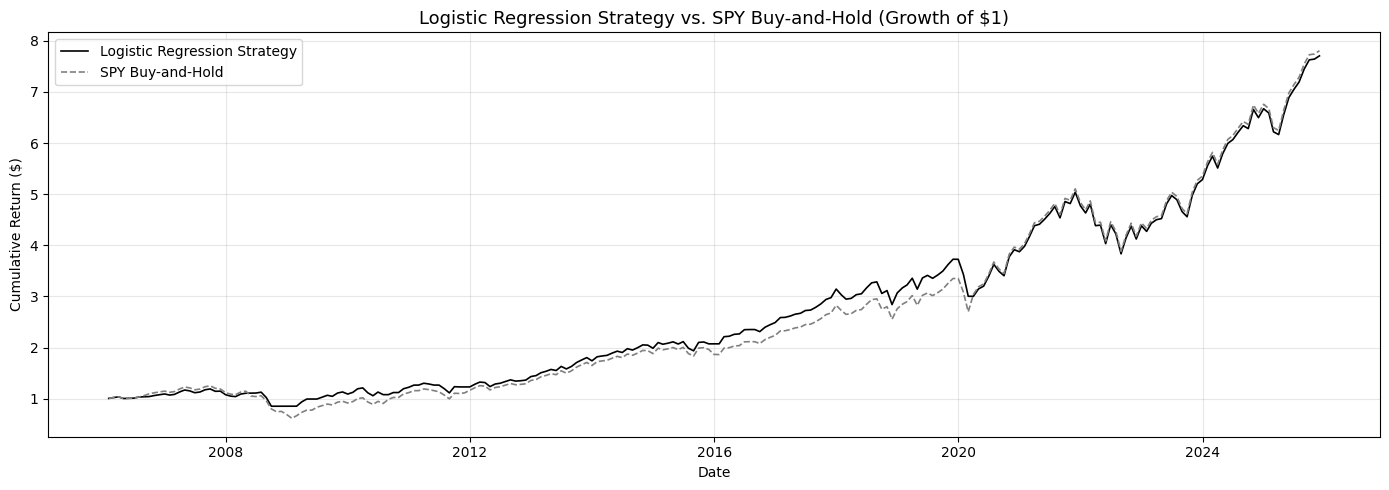

In [ ]:
# ============================================================
# Equity Curve: Logistic Regression Strategy vs. Buy-and-Hold
# ============================================================
# Grayscale-friendly: solid line for strategy, dashed for
# benchmark. Monthly data produces a smoother curve than
# the daily charts in Notebook 1.
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_eval.index, df_eval['strategy_cumulative'],
    color='black', linewidth=1.2, linestyle='-',
    label='Logistic Regression Strategy'
)
ax.plot(
    df_eval.index, df_eval['buyhold_cumulative'],
    color='grey', linewidth=1.2, linestyle='--',
    label='SPY Buy-and-Hold'
)

ax.set_title('Logistic Regression Strategy vs. SPY Buy-and-Hold (Growth of $1)',
             fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return ($)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The equity curve confirms what the confusion matrix warned us about. The strategy's entire edge came from avoiding parts of the 2008 financial crisis and the 2020 COVID crash. You can see the solid line stay above the dashed line through those drawdowns, with the gap widest around 2009 and early 2020.

But look at what happens after each crash. The strategy gave back its advantage during the recoveries, particularly after COVID. The model, having seen a period of extreme volatility and negative returns, continued to predict "down" during the early months of the recovery when the strongest gains occurred. By the end of 2025, the two lines have converged completely.

This is the fundamental trap of a defensive timing model:

- **Avoiding the crash is the easy part.** When every feature (VIX elevated, realized vol spiking, recent returns deeply negative) is screaming "danger," even a weak model can predict "down." Those are the 10 correct bearish calls that cut max drawdown in half.
- **Re-entering after the crash is the hard part.** The same features that correctly flagged the crash remain elevated during the early recovery. VIX is still high. Realized vol is still high. Recent 3-month and 12-month returns are still deeply negative. The model sees all of this and keeps predicting "down" while the market rips upward. By the time the features normalize and the model shifts back to "up," the best gains are already behind you.

This is not a flaw specific to logistic regression. Any model trained on these features will exhibit the same behavior, because the features themselves are backward-looking. They describe what has already happened, not what is about to change. The 2020 recovery, where SPY gained over 70% from its March low through year-end, is the textbook example: every indicator said "crisis" while the market was already recovering.

Now we examine whether the model's coefficients were at least stable over time, or whether the model was constantly changing its mind about which features matter.

## Section 4: Coefficient Stability Over Time

A reliable model should produce stable coefficients as the training window expands. If the coefficient for a feature flips between positive and negative depending on which years are in the training set, that feature is not providing a consistent signal. It is fitting noise in one period and different noise in another.

We stored the model coefficients at each step of the expanding-window loop. The chart below plots each coefficient over time, showing how the model's view of each feature evolved as it absorbed more data.

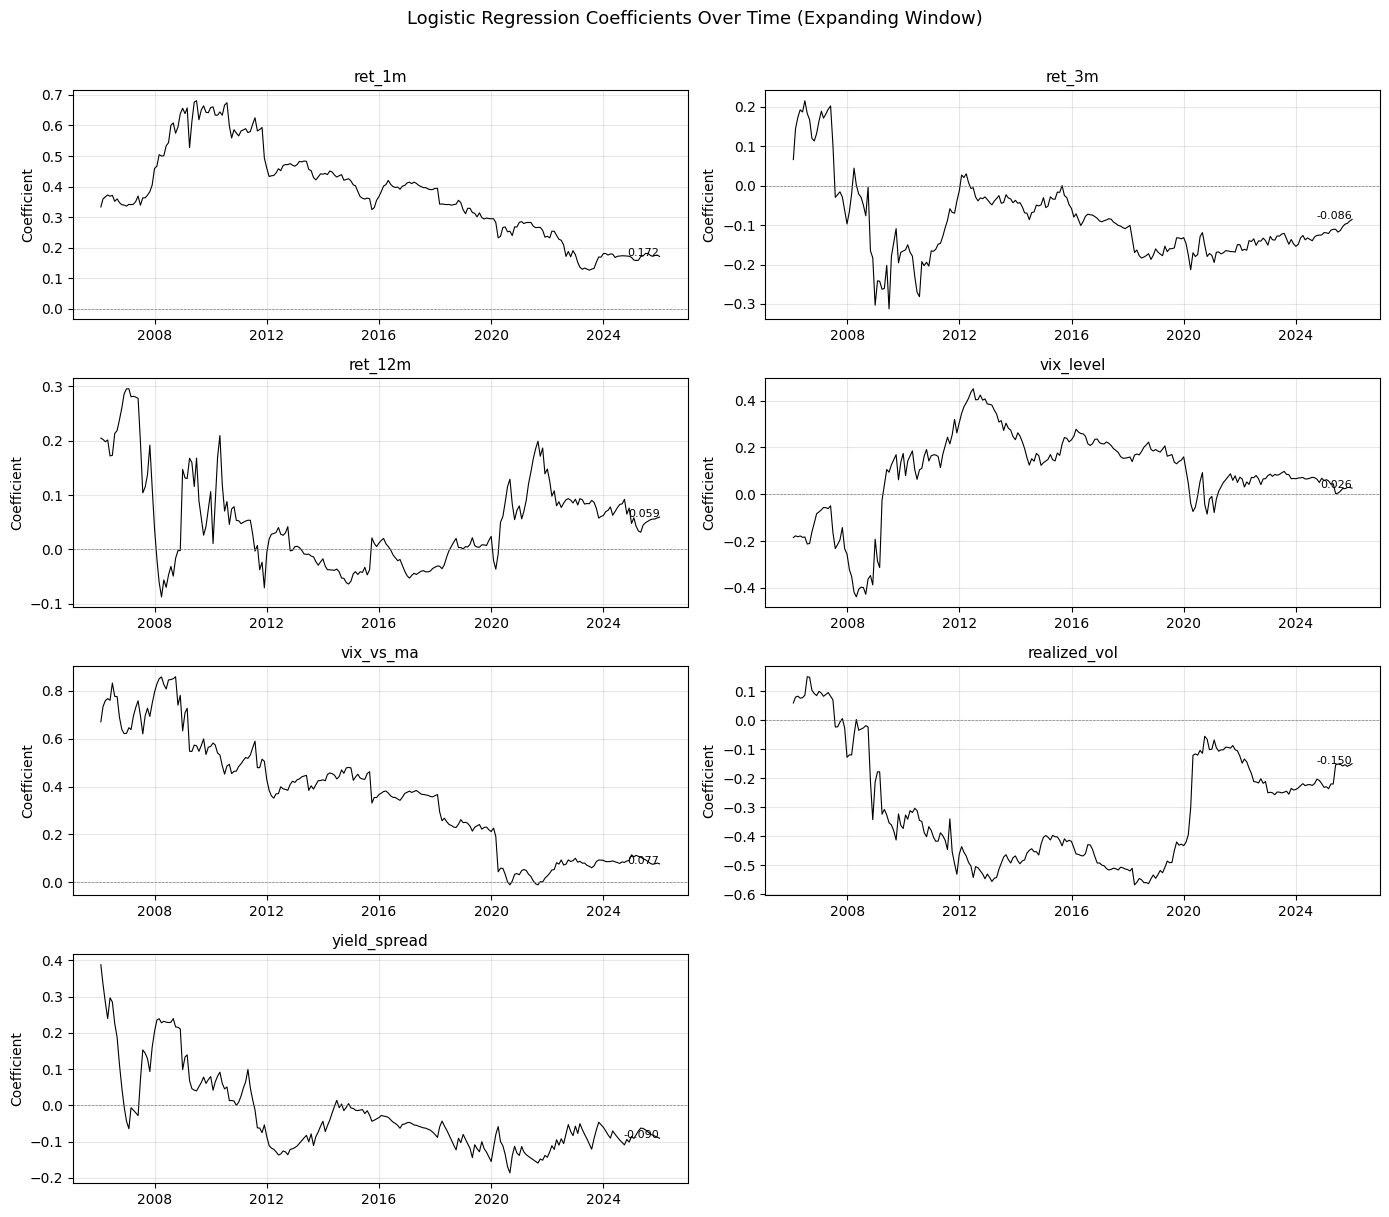

Final model coefficients (standardized features):
           ret_1m: +0.1716  (sign changes: 0)
           ret_3m: -0.0855  (sign changes: 7)
          ret_12m: +0.0594  (sign changes: 14)
        vix_level: +0.0260  (sign changes: 5)
        vix_vs_ma: +0.0770  (sign changes: 4)
     realized_vol: -0.1505  (sign changes: 5)
     yield_spread: -0.0904  (sign changes: 9)


In [ ]:
# ============================================================
# Coefficient Stability Over Time
# ============================================================
# We plot the coefficient for each feature across all 240
# expanding-window iterations. Stable, useful features should
# show coefficients that settle to a consistent value as the
# training window grows. Unreliable features will show
# coefficients that wander, change sign, or oscillate.
#
# Note: coefficients are on standardized features, so their
# magnitudes are directly comparable. A coefficient of 0.3
# on one feature has the same scale as 0.3 on another.
# ============================================================

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.plot(df_coefs.index, df_coefs[col], color='black', linewidth=0.8)
    ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.5)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Coefficient')
    ax.grid(True, alpha=0.3)

    # Annotate with final value
    final_val = df_coefs[col].iloc[-1]
    ax.annotate(
        f'{final_val:.3f}',
        xy=(df_coefs.index[-1], final_val),
        fontsize=8, ha='right'
    )

# Hide the unused 8th subplot
axes[7].set_visible(False)

plt.suptitle('Logistic Regression Coefficients Over Time (Expanding Window)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Print final coefficients for reference
print("Final model coefficients (standardized features):")
print("=" * 50)
for col in feature_cols:
    val = df_coefs[col].iloc[-1]
    sign_changes = ((df_coefs[col].values[:-1] * df_coefs[col].values[1:]) < 0).sum()
    print(f"  {col:>15s}: {val:+.4f}  (sign changes: {sign_changes})")

The coefficient plots raise a question that matters for any time-series model: are changing coefficients a sign of instability, or a sign of healthy adaptation to evolving market regimes?

Going through each feature:

- **ret_1m (0 sign changes):** the most stable coefficient. It stays positive throughout, meaning recent positive returns predict continued positive direction. But even this feature declined from 0.5 in the early period to 0.17 by the end. The model's confidence in its best feature has been fading for 15 years.
- **ret_3m (7 sign changes):** started positive, flipped negative around 2010, and stayed there. The model initially interpreted 3-month returns as momentum (positive predicts positive) and later switched to mean-reversion (positive predicts negative).
- **ret_12m (14 sign changes):** the least stable feature. Fourteen sign changes in 240 months means the model changed its mind about whether long-term momentum is bullish or bearish roughly every 17 months.
- **vix_level (5 sign changes):** wild early swings between -0.4 and +0.4, gradually settling near zero. The model cannot decide whether high VIX predicts up months (the volatility risk premium argument) or down months (fear signals further declines).
- **vix_vs_ma (4 sign changes):** started as the strongest coefficient at 0.8, suggesting VIX above its moving average predicted up months. By 2025 it has collapsed to 0.08.
- **realized_vol (5 sign changes):** the most consistently negative coefficient after the early period, meaning high recent volatility predicts down months. The sharp jump around 2020 is the COVID crash entering the training set.
- **yield_spread (9 sign changes):** started positive (steeper curve predicts up), flipped to negative around 2014, and stayed there.

### Instability or adaptation?

The answer is not straightforward, and it matters for how you interpret any model, not just this one.

**The case for adaptation:** market structure genuinely evolves. The yield curve's relationship to equity returns may be fundamentally different post-2008, when central bank policy dominated the term structure. VIX's predictive power may have shifted as the volatility products ecosystem (futures, ETPs) grew and changed how fear is priced. A model that stubbornly held the same coefficients through all of that would be ignoring real structural changes. The `vix_level` coefficient starting negative, swinging positive after 2008, and settling near zero could plausibly reflect a real shift in how volatility is priced.

**The case for instability:** if the relationships were real but regime-dependent, you would expect the model to perform well within each regime, even if the coefficients differed across regimes. But it does not. It predicts "up" 92% of the time regardless of what the coefficients are doing. The coefficients are moving, but the output barely changes. That suggests the features are too weak to overcome the class prior (64.7% up months) no matter what weights the model assigns. And `ret_12m` with 14 sign changes is hard to justify as regime adaptation, because regimes do not switch every 17 months in an alternating pattern.

**The practical problem:** with 300 monthly observations, weak correlations, and a linear model, we cannot distinguish "the relationship genuinely changed" from "there was never a stable relationship to begin with." Both explanations fit the data. We also chose an expanding window, which cannot truly adapt to regimes because it never forgets old data. When a coefficient shifts, it is not because the model dropped pre-2014 observations and recalibrated. It is because new observations are pulling the coefficient in a different direction against the weight of all prior history. That is a tug-of-war between old data and new data, not regime detection.

**The resolution:** when you combine changing coefficients with weak predictive power and no improvement in out-of-sample accuracy, the most parsimonious explanation is that the features do not contain enough signal to produce stable estimates. If the model were genuinely adapting to regimes and benefiting from it, you would see that in the equity curve or the classification report. We do not. The model matches the naive baseline regardless of how its coefficients shift.

This kind of coefficient analysis is a useful diagnostic for any model, not just logistic regression. If you build a more complex model in Chapter 14 and find its feature importance rankings shuffling across different training windows, ask the same question: is performance improving as the rankings change, or is the model just rearranging weak signals? The answer determines whether you are looking at adaptation or noise.

## Section 5: Key Takeaways

This notebook applied logistic regression to predict monthly SPY direction using seven features with documented economic rationale, evaluated with expanding-window out-of-sample methodology.

| | Result |
|---|---|
| Model accuracy | 67.1% (identical to naive baseline) |
| Predicted "up" | 91.7% of months |
| Down months identified | 10 out of 79 (12.7%) |
| CAGR vs. buy-and-hold | 10.80% vs. 10.87% (no improvement) |
| Max drawdown vs. buy-and-hold | -28.38% vs. -50.78% (better, but fragile) |
| Coefficient stability | Only 1 of 7 features held a consistent sign |

Four conclusions carry forward:

1. **Adding features did not solve the problem.** Notebook 1 showed that price history alone (ARIMA) cannot predict equity returns. This notebook added momentum at three horizons, volatility, fear, and the yield curve. The result was the same: the model could not beat the naive baseline of "the market usually goes up."
2. **Classification metrics and trading performance measure different things.** A useless classification report (67.1% accuracy, 12.7% recall on down months) produced a backtest with half the drawdown of buy-and-hold. A few correct bearish calls at the right time can dominate the equity curve even when the model is wrong most of the time. Always evaluate both.
3. **Changing coefficients are not automatically bad, but they are a warning.** When coefficients shift and model performance does not improve, the most likely explanation is that the features are too weak to estimate reliably, not that the model is adapting to new regimes.
4. **The academic evidence holds.** Welch and Goyal (2008) tested a comprehensive set of predictive variables and found they fail out of sample. Our result, with different features, a different model, and 17 additional years of data, arrives at the same conclusion.

In Notebook 3, we test Prophet, the model that has generated the most misleading online content about stock price prediction. The failure mode is different but the conclusion is the same.